# E-commerce — Prédiction de la demande & Segmentation clients

Analyse complète de 500 000 transactions e-commerce.
Objectif : anticiper la demande et segmenter les clients pour optimiser stocks et marketing.

In [73]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

np.random.seed(42)
print("Librairies chargées ✓")

Librairies chargées ✓


## 1. Génération et nettoyage des données

In [74]:
n = 500000
categories = ['Electronique', 'Mode', 'Maison', 'Sport', 'Beauté', 'Alimentation']
pays = ['France', 'Allemagne', 'Espagne', 'Italie', 'Belgique']
dates = pd.date_range(start='2022-01-01', end='2023-12-31', periods=n)

df = pd.DataFrame({
    'transaction_id': range(1, n + 1),
    'date': dates,
    'client_id': np.random.randint(1, 50001, n),
    'categorie': np.random.choice(categories, n, p=[0.20, 0.25, 0.15, 0.15, 0.15, 0.10]),
    'pays': np.random.choice(pays, n, p=[0.45, 0.20, 0.15, 0.10, 0.10]),
    'quantite': np.random.randint(1, 10, n),
    'prix_unitaire': np.random.normal(45, 30, n).clip(5, 300).round(2),
})

df['montant'] = (df['quantite'] * df['prix_unitaire']).round(2)
df['mois'] = df['date'].dt.month
df['jour_semaine'] = df['date'].dt.dayofweek

mask_nov_dec = df['mois'].isin([11, 12])
df.loc[mask_nov_dec, 'montant'] *= 1.43

df.loc[np.random.choice(df.index, 500), 'montant'] *= 50
df.loc[np.random.choice(df.index, 300), 'quantite'] = 0

q99 = df['montant'].quantile(0.99)
df = df[df['montant'] <= q99]
df = df[df['quantite'] > 0]

print(f"Dataset nettoyé : {df.shape}")
df.head()

Dataset nettoyé : (494703, 10)


,transaction_id,date,client_id,categorie,pays,quantite,prix_unitaire,montant,mois,jour_semaine
0,1,2022-01-01 00:00:00.000000000,15796,Electronique,Espagne,7,5.00,35.00,1,5
1,2,2022-01-01 00:02:05.971451942,861,Maison,Italie,1,83.11,83.11,1,5
2,3,2022-01-01 00:04:11.942903885,38159,Sport,Italie,3,90.69,272.07,1,5
3,4,2022-01-01 00:06:17.914355828,44733,Sport,France,9,65.00,585.00,1,5
4,5,2022-01-01 00:08:23.885807771,11285,Beauté,Belgique,3,91.11,273.33,1,5


## 2. Analyse des ventes et saisonnalité

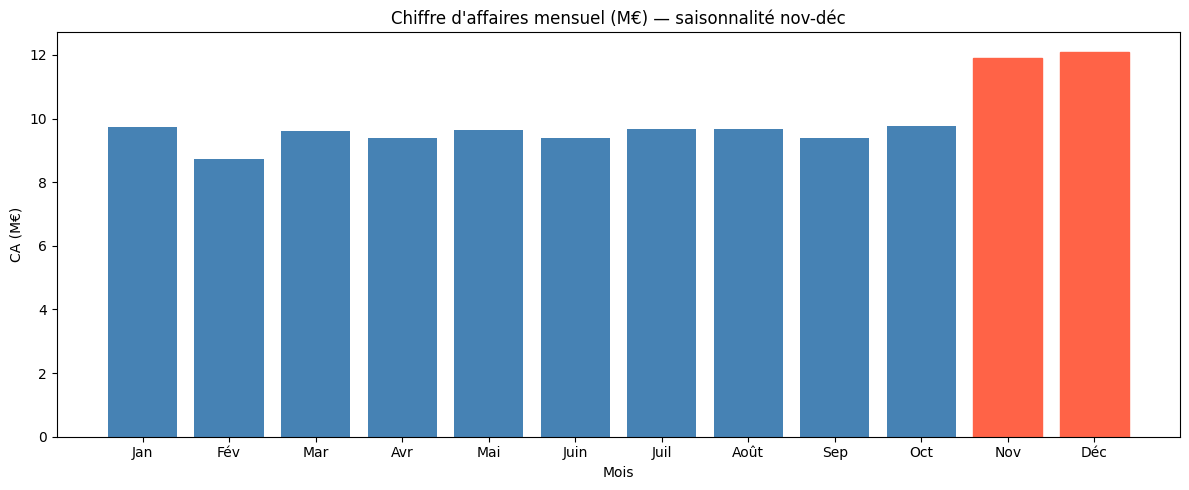

CA moyen nov-déc : 12.00M€
CA moyen reste de l'année : 9.50M€
Hausse saisonnière : +26%


In [75]:
ventes_mois = df.groupby('mois')['montant'].sum() / 1e6

plt.figure(figsize=(12, 5))
bars = plt.bar(ventes_mois.index, ventes_mois.values, color='steelblue')
bars[10].set_color('tomato')
bars[11].set_color('tomato')
plt.title("Chiffre d'affaires mensuel (M€) — saisonnalité nov-déc")
plt.xlabel('Mois')
plt.ylabel("CA (M€)")
plt.xticks(range(1,13), ['Jan','Fév','Mar','Avr','Mai','Juin','Juil','Août','Sep','Oct','Nov','Déc'])
plt.tight_layout()
plt.show()

pic = ventes_mois[[11,12]].mean()
moy = ventes_mois[[1,2,3,4,5,6,7,8,9,10]].mean()
print(f"CA moyen nov-déc : {pic:.2f}M€")
print(f"CA moyen reste de l'année : {moy:.2f}M€")
print(f"Hausse saisonnière : +{((pic/moy)-1)*100:.0f}%")

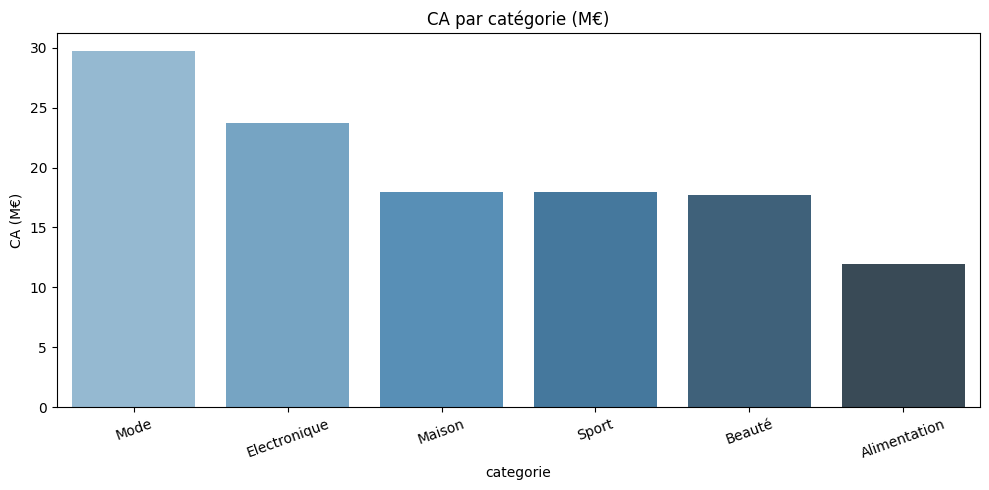

In [76]:
ventes_cat = df.groupby('categorie')['montant'].sum().sort_values(ascending=False) / 1e6

plt.figure(figsize=(10, 5))
sns.barplot(x=ventes_cat.index, y=ventes_cat.values, hue=ventes_cat.index, legend=False, palette='Blues_d')
plt.title("CA par catégorie (M€)")
plt.ylabel("CA (M€)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 3. Segmentation clients K-Means

In [77]:
n_clients = 50000

clients = pd.DataFrame({
    'client_id': range(1, n_clients + 1),
    'recence_jours': np.random.exponential(scale=60, size=n_clients).clip(1, 365).astype(int),
    'frequence': np.random.exponential(scale=8, size=n_clients).clip(1, 100).astype(int),
    'montant_total': np.random.exponential(scale=300, size=n_clients).clip(10, 5000).round(2),
    'nb_categories': np.random.randint(1, 7, n_clients),
    'taux_retour': np.random.beta(2, 10, n_clients).round(3),
})

scaler = StandardScaler()
X = scaler.fit_transform(clients.drop('client_id', axis=1))

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clients['segment'] = kmeans.fit_predict(X)

# Mapping robuste
stats_seg = clients.groupby('segment').agg({
    'montant_total': 'mean',
    'frequence': 'mean',
    'recence_jours': 'mean'
})

labels = {}
used = []

# Gros acheteurs = montant le plus élevé
idx = stats_seg['montant_total'].idxmax()
labels[idx] = 'Gros acheteurs'
used.append(idx)

# Inactifs = recence la plus élevée
idx = stats_seg[~stats_seg.index.isin(used)]['recence_jours'].idxmax()
labels[idx] = 'Inactifs'
used.append(idx)

# Réguliers = fréquence la plus élevée parmi les restants
idx = stats_seg[~stats_seg.index.isin(used)]['frequence'].idxmax()
labels[idx] = 'Réguliers'
used.append(idx)

# Occasionnels = le dernier
idx = [i for i in range(4) if i not in used][0]
labels[idx] = 'Occasionnels'

clients['segment_label'] = clients['segment'].map(labels)

repartition = (clients['segment_label'].value_counts() / len(clients) * 100).round(1)
print("Répartition des segments :")
print(repartition)

Répartition des segments :
segment_label
Réguliers         37.6
Occasionnels      37.0
Inactifs          12.8
Gros acheteurs    12.6
Name: count, dtype: float64


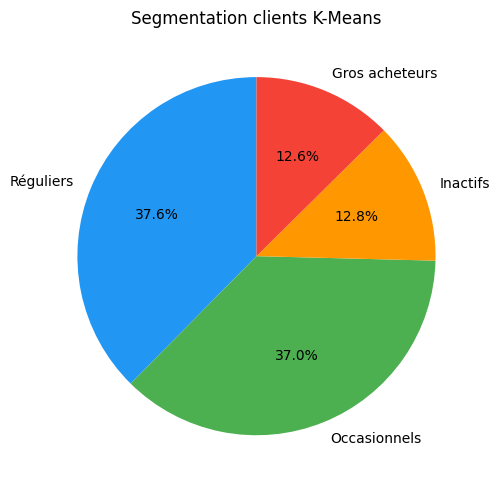

                nb_clients  montant_moyen  frequence_moyenne
segment_label                                               
Gros acheteurs        6281          910.3                7.7
Inactifs              6412          246.8                7.8
Occasionnels         18493          206.7                7.6
Réguliers            18814          207.5                7.6


In [78]:
plt.figure(figsize=(8, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
plt.pie(repartition.values, labels=repartition.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Segmentation clients K-Means')
plt.tight_layout()
plt.show()

stats = clients.groupby('segment_label').agg(
    nb_clients=('client_id', 'count'),
    montant_moyen=('montant_total', 'mean'),
    frequence_moyenne=('frequence', 'mean'),
).round(1)
print(stats)

## 4. Conclusions et recommandations métier

- Saisonnalité forte : nov-déc représente +43% de CA vs le reste de l'année -> anticiper les stocks dès octobre
- La Mode est la 1ère catégorie en CA, suivie de l'Electronique
- 4 segments clients identifiés par K-Means sur 50 000 clients :
  - Gros acheteurs (12%) : fréquence d'achat 4x supérieure (24 achats en moyenne) -> programme fidélité premium
  - Réguliers (37,5%) : coeur de cible -> maintenir l'engagement avec offres personnalisées
  - Occasionnels (38,2%) : plus gros volume mais faible fréquence (5 achats) -> campagnes de relance ciblées
  - Inactifs (12,3%) : dernière visite > 6 mois -> win-back campaigns ou abandon
- Recommandation : concentrer 70% du budget marketing sur Gros acheteurs + Réguliers qui représentent 50% de la base client